# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [4]:
npts = 2**10

## Power Spectrum Simulation H=0.8

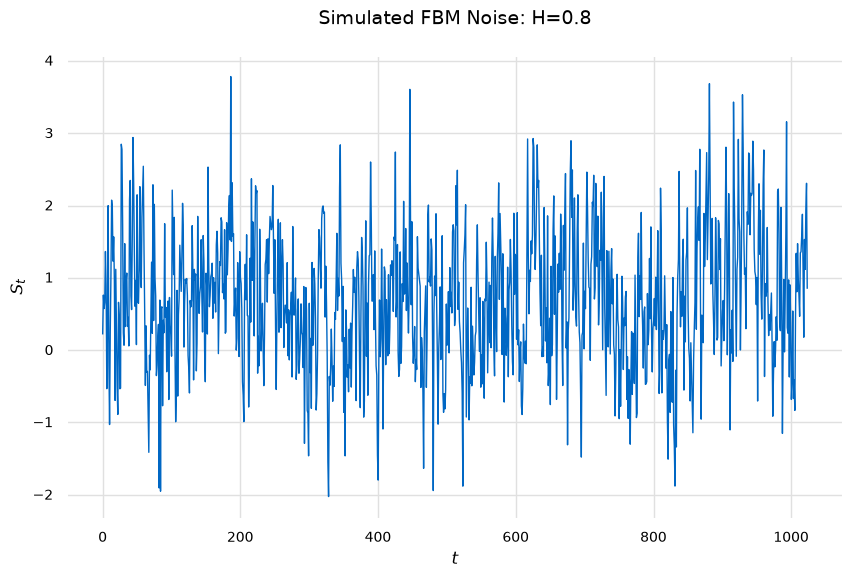

In [5]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

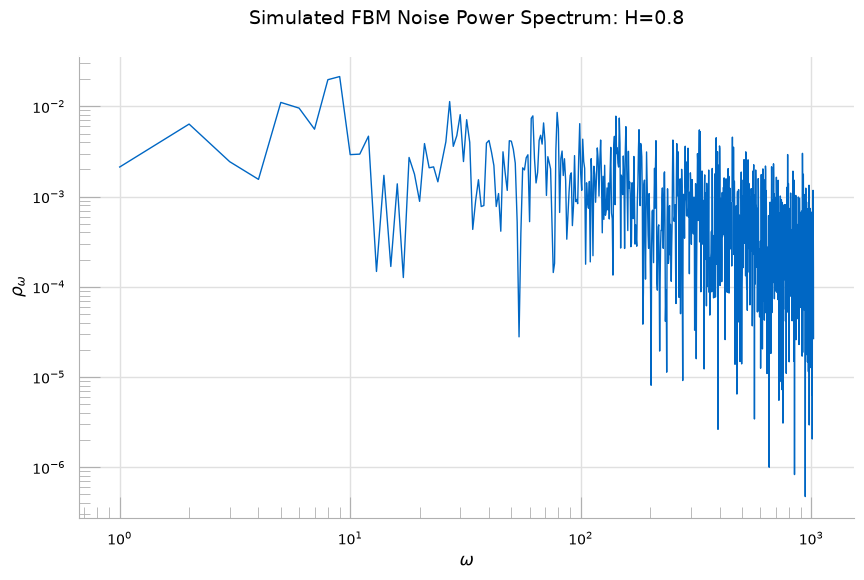

In [6]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [7]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     271.9
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           2.42e-54
Time:                        16:48:22   Log-Likelihood:                -857.50
No. Observations:                1023   AIC:                             1719.
Df Residuals:                    1021   BIC:                             1729.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6302      0.107    -15.247      0.000      -1.840      -1.420
x1            -0.6748      0.041    -16.490      0.000      -0.755      -0.595
==============================================================================
Omnibus:                      171.828   Durbin-Watson:                   1.442
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.118
Skew:                          -1.034   Prob(JB):                     5.55e-67
Kurtosis:                       4.698   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -1.630229593928883,
      "err": 0.1069195807940494,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e75bae07-010f-47fb-888f-848740a44712",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.6748273602114845,
         "err": 0.040922762266975006,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "e75bae07-010f-47fb-888f-848740a44712",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.21032011738462053,
   "param_transforms": [
      {
         "param": {
            "est": 0.8374136801057422,
            "err": 0.020461381133487503,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "ord

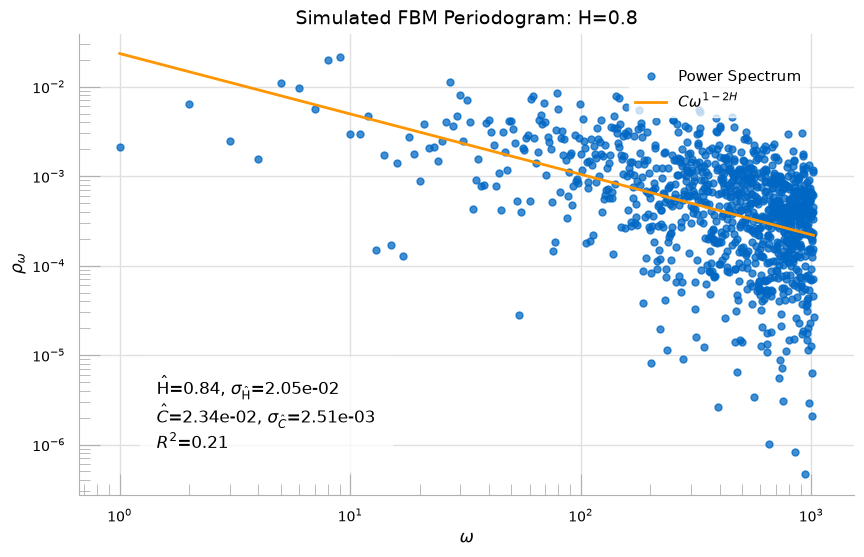

In [9]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

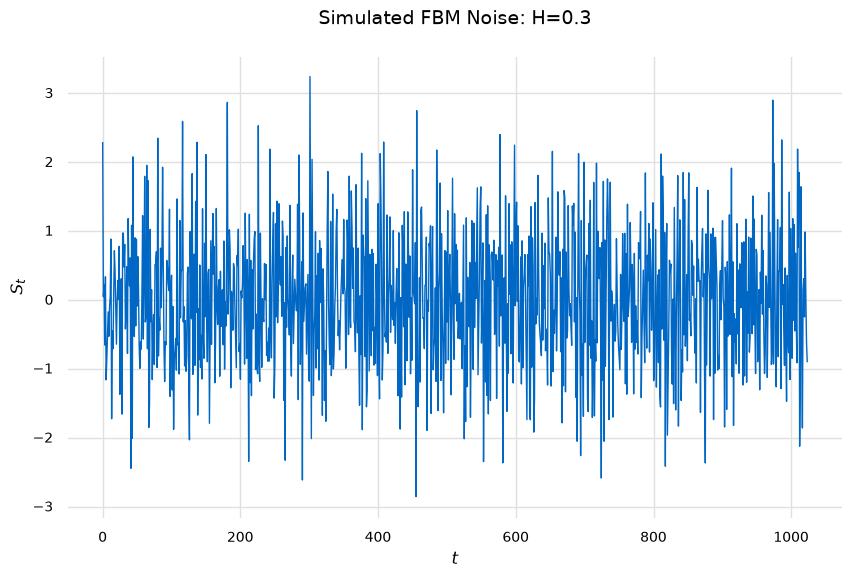

In [10]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

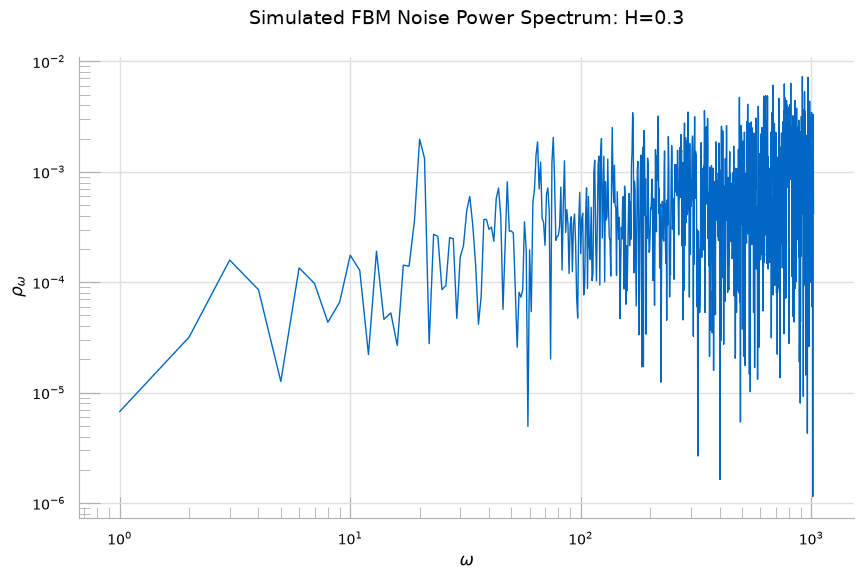

In [11]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [12]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     107.5
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           5.01e-24
Time:                        16:48:22   Log-Likelihood:                -843.26
No. Observations:                1023   AIC:                             1691.
Df Residuals:                    1021   BIC:                             1700.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3680      0.105    -41.426      0.000      -4.575      -4.161
x1             0.4185      0.040     10.371      0.000       0.339       0.498
==============================================================================
Omnibus:                      183.985   Durbin-Watson:                   1.489
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              337.632
Skew:                          -1.083   Prob(JB):                     4.83e-74
Kurtosis:                       4.796   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -4.36800754467064,
      "err": 0.10544169662845142,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "f3e13950-7466-4309-b2de-274966a370f1",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.41852715255574724,
         "err": 0.04035711187891943,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "f3e13950-7466-4309-b2de-274966a370f1",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.09529862373969245,
   "param_transforms": [
      {
         "param": {
            "est": 0.2907364237221264,
            "err": 0.020178555939459716,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "orde

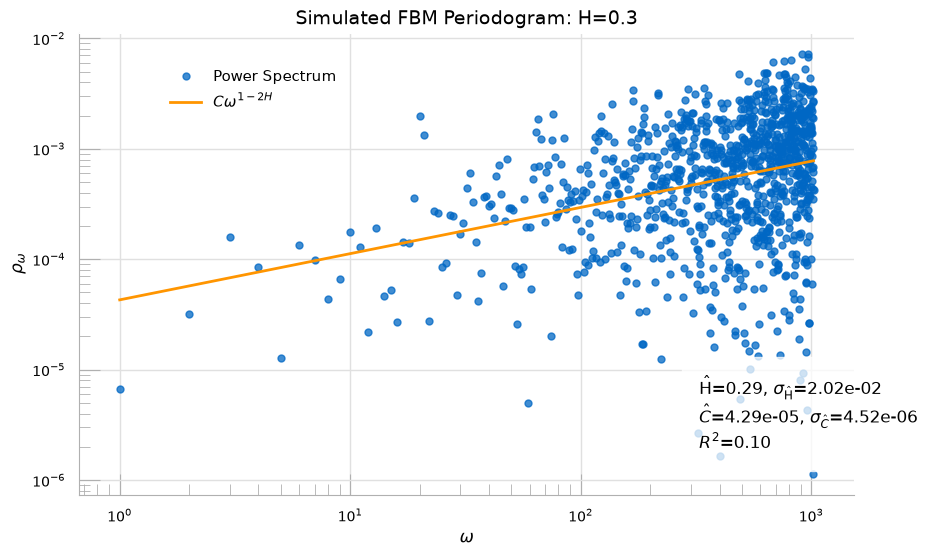

In [14]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.95

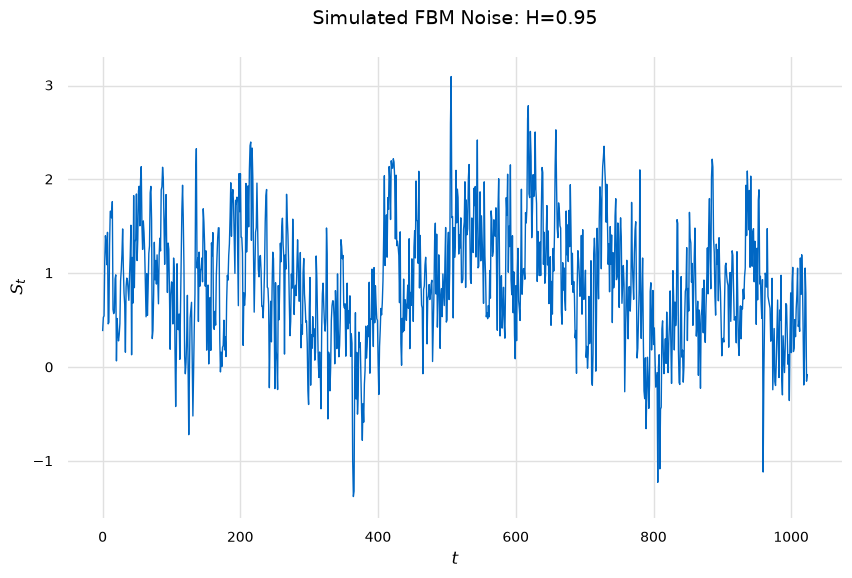

In [36]:
H = 0.95
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

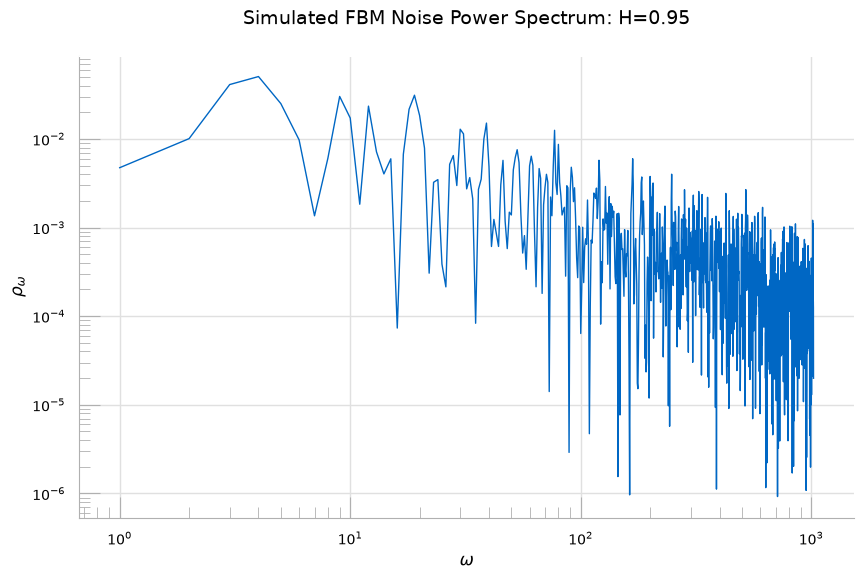

In [37]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [38]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     429.0
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           7.74e-80
Time:                        16:55:21   Log-Likelihood:                -920.51
No. Observations:                1023   AIC:                             1845.
Df Residuals:                    1021   BIC:                             1855.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2458      0.114    -10.956      0.000      -1.469      -1.023
x1            -0.9015      0.044    -20.713      0.000      -0.987      -0.816
==============================================================================
Omnibus:                      194.544   Durbin-Watson:                   1.417
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              359.201
Skew:                          -1.139   Prob(JB):                     1.00e-78
Kurtosis:                       4.799   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [39]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -1.2458050331966515,
      "err": 0.11371210904856983,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "83455ea7-6ecb-4c76-89a1-ef94297b25de",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.9014629006598247,
         "err": 0.04352255752325159,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "83455ea7-6ecb-4c76-89a1-ef94297b25de",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.29586667802507016,
   "param_transforms": [
      {
         "param": {
            "est": 0.9507314503299124,
            "err": 0.021761278761625796,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "or

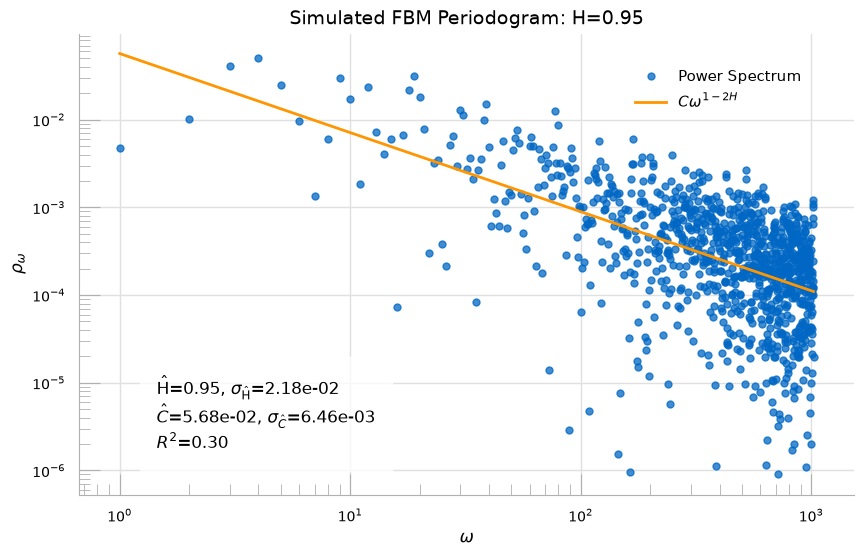

In [40]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")